#<font color='darkgreen'>Desafío- Detección temprana de renuncias en empresa de telecomunicaciones</font>

##<font color='darkgreen'>Descripción</font>

<p>
La oferta de servicios de telefonía ha ido en aumento en los últimos años, provocando una alta competencia que se traduce en menores precios y mejores prestaciones. Sin embargo, estas empresas luchan día a día por retener a sus clientes ya que el costo de un nuevo cliente es mayor que el de retener a un cliente antiguo.
</p>

<p>
El objetivo de este desafío es entrenar un modelo de ensamble que permita predecir tempranamente si un cliente renunciará a la compañía, además de poder explicar cuál o cuáles son las características que más incidencia tienen en la separación de clientes con y sin renuncia. Para esto deberás aplicar los conceptos y herramientas aprendidas hasta ahora.
</p>

<p>
La muestra con la que se trabajará es un archivo llamado <b>telecom_churn.csv</b>, que contiene
los siguientes atributos asociados a clientes:
</p>

* Churn (Variable objetivo): valor 1 si el cliente canceló el servicio, 0 si no
* AccountWeeks: número de semanas que el cliente ha tenido activa la cuenta
* ContractRenewal: toma el valor 1 si el cliente ha renovado recientemente el contrato,
0 encaso contrario
* DataPlan: valor 1 si el cliente tiene plan de datos, 0 en caso contrario
* DataUsage: Gigabytes de uso mensual de datos
* CustServCalls: número de llamadas al servicio de atención al cliente
* DayMins: promedio de minutos diurnos al mes
* DayCalls: número medio de llamadas diurnas
* MonthlyCharge: factura mensual media
* OverageFee: mayor cuota de exceso en los últimos 12 meses
* RoamMin: minutos de Roaming

Para lograr lo solicitado, debes realizar las siguientes tareas:

1. Importa las librerías necesarias y la base de datos, y realiza un análisis por variable
usando visualizaciones. Debes considerar las posibles correlaciones y representarlas
en un heatmap.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('telecom_churn.csv')
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


<Axes: >

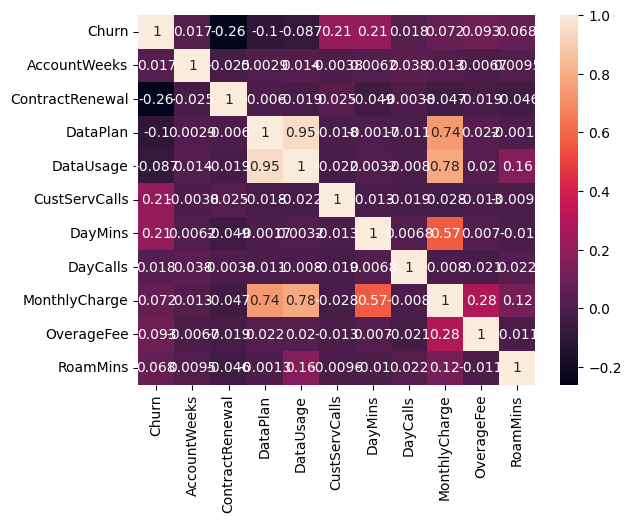

In [4]:
#generar heatmap
sns.heatmap(df.corr(), annot=True)

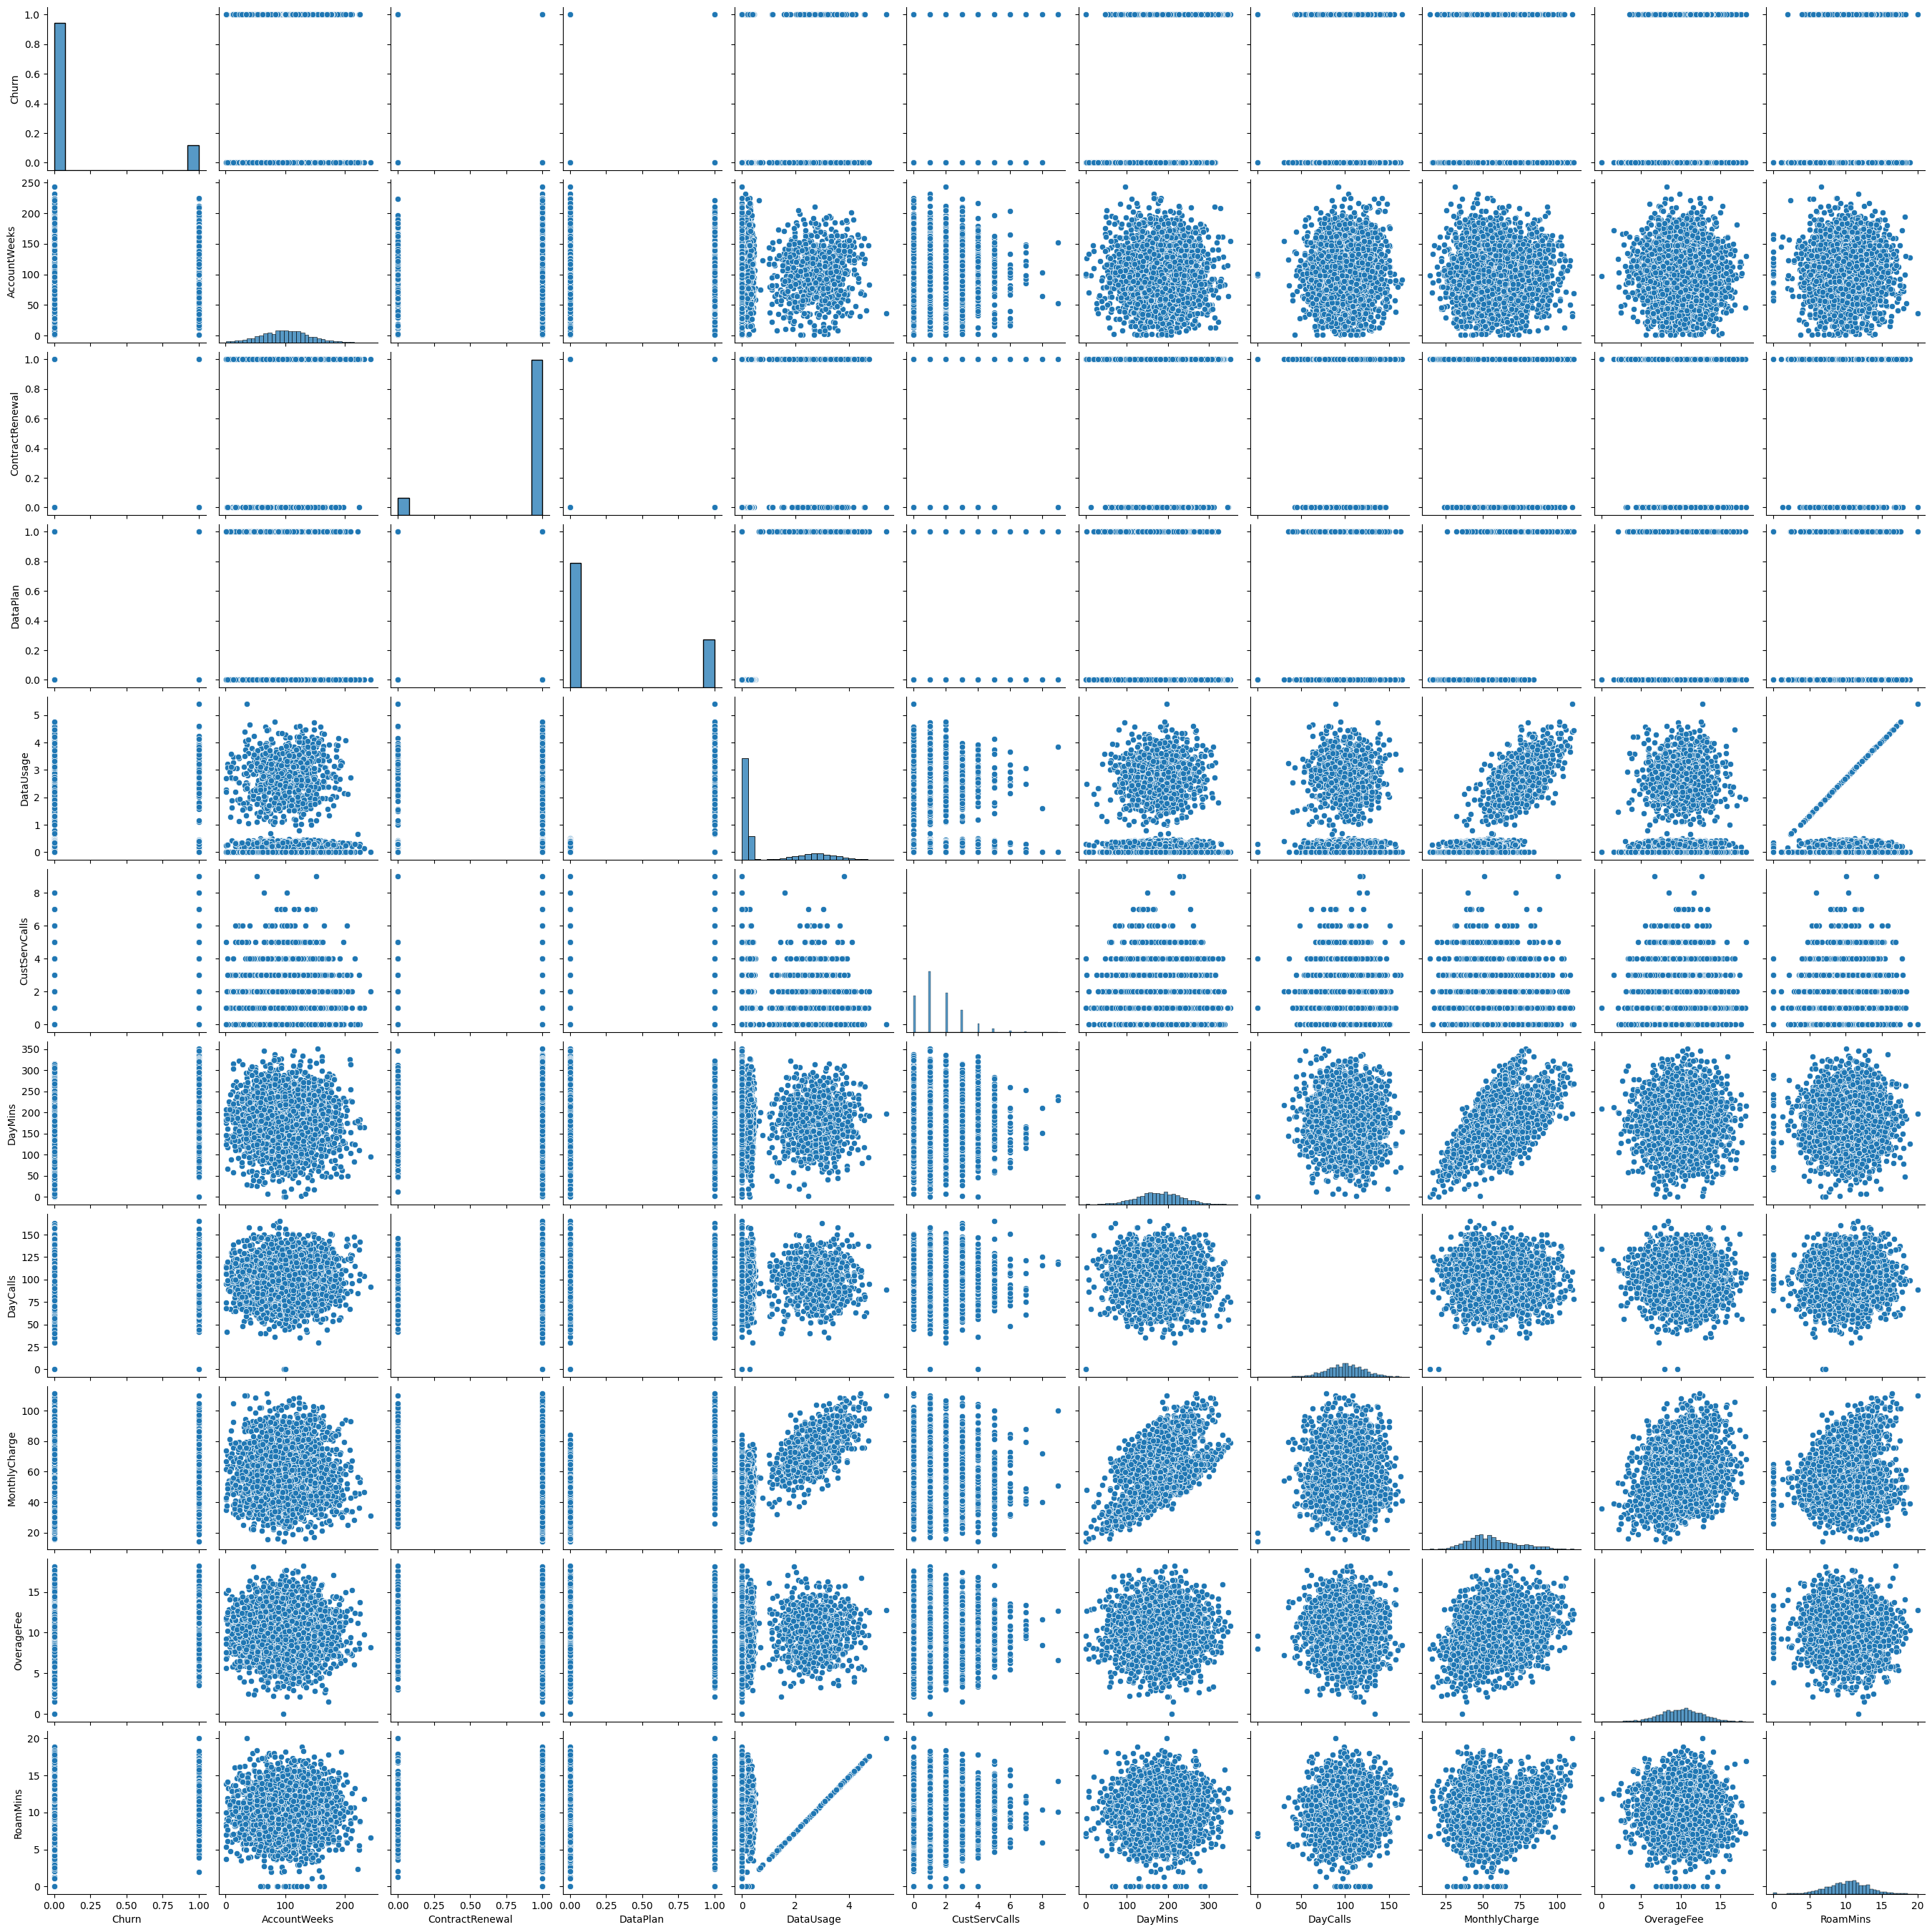

In [5]:
sns.pairplot(df)

2. Desarrolla un modelo de árbol de decisión sin modificar sus hiper parámetros y despliega sus métricas de desempeño. Luego, mejora este modelo de forma de
evitar el overfitting usando búsqueda por grilla con 5 kfold:

* max_depth: [5, 10, 15, 20, 25]
* min_samples_split: [0.01, 0.02, 0.03, 0.04]

Da a conocer los mejores hiper parámetros encontrados y el desempeño del modelo,
tanto en los datos de entrenamiento como en los de test.

In [7]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
yhat = tree_default.predict(x_test)
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       857
           1       0.57      0.67      0.62       143

    accuracy                           0.88      1000
   macro avg       0.76      0.79      0.77      1000
weighted avg       0.89      0.88      0.89      1000



In [13]:
param_grid = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [0.01, 0.02, 0.03, 0.04]
}

In [14]:
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, 20, 25],
                         'min_samples_split': [0.01, 0.02, 0.03, 0.04]},
             scoring='f1')

In [15]:
grid_search_yhat = grid_search.predict(x_test)
print(classification_report(y_test, grid_search_yhat))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       857
           1       0.85      0.58      0.69       143

    accuracy                           0.93      1000
   macro avg       0.89      0.78      0.82      1000
weighted avg       0.92      0.93      0.92      1000



In [16]:
print("Mejor F1-Score en validación:", grid_search.best_score_)

Mejor F1-Score en validación: 0.6900099175688876


### El árbol con grid da mejores resultados que el árbol por defecto. donde más se nota es en la precisión que da un salto de 0.57 a 0.85 para los que hace churn lo que permite predecir con muchas mas presición quienes se van.

### El recall bajó en el árbol con grid, por lo que podriamos encontrar menos clientes que quieran irse pero los que si encontramos es seguro se si se van.

3. Balancea las clases usando SMOTE para el conjunto de entrenamiento. Luego, aplica
un modelo de Bagging con 200 estimadores y muestra las métricas sobre el conjunto
de test.

In [17]:
pip install imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import BaggingClassifier

In [22]:
sm = SMOTE(random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)

print(f"Antes de SMOTE {y_train.value_counts()}")
print(f"Después de SMOTE {y_train_sm.value_counts()}")

Antes de SMOTE Churn
0    1993
1     340
Name: count, dtype: int64
Después de SMOTE Churn
0    1993
1    1993
Name: count, dtype: int64


aplicamos bagging

In [33]:
bagg_model = BaggingClassifier(random_state=42, n_estimators=200, oob_score=True)
bagg_model.fit(x_train_sm, y_train_sm)

BaggingClassifier(n_estimators=200, oob_score=True, random_state=42)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

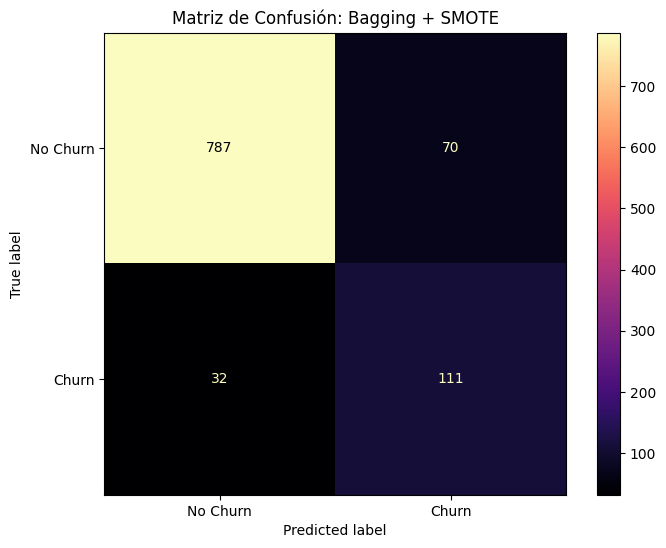

In [35]:
y_pred = bagg_model.predict(x_test)
y_probs = bagg_model.predict_proba(x_test)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Churn', 'Churn'], cmap='magma', ax=ax)
plt.title('Matriz de Confusión: Bagging + SMOTE')
plt.show()

### la matriz muestra que predecimos que 787 se quedan, 70 los clientes que creimos que se irian pero no se fueron, 32 que si se fueron y no los consideramos

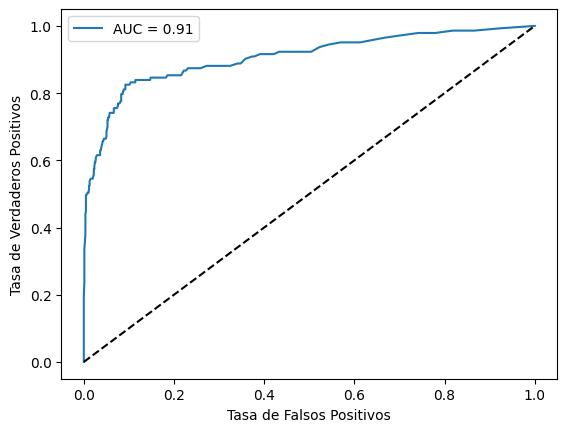

In [36]:
y_probs = bagg_model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # Línea aleatoria
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()

### el codo me indica que solo nos equivocamos el 10% de las veces. optimizando la cantidad de personas a las que le mandamos promociones

In [37]:
print(f"OOB Score: {bagg_model.oob_score_}")

OOB Score: 0.9332664325137983


### el ensamble de 200 arboles generaliza bien, no memoriza el ruido y aprende patrones reales

4. Implementa un modelo de Bagging usando modelos heterogéneos con los
siguientes estimadores: Regresión Logística, Árbol de decisión, y dos SVM de
clasificación con kernel ‘rbf’ y ‘sigmoid’. Para ello considera 200 muestras bootstrap
(T).

Debes calibrar la importancia de los modelos, repitiendo el modelo que sea más
importante en la lista de modelos a entrenar. Considera que un mejor modelo es
aquel con mejor f1-score. Muestra las métricas del modelo final aplicado al conjunto
de test. (Para realizar esta tarea utiliza la función bagging_het que se encuentra en el
archivo util_bagging.py)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score

In [40]:
# 1. Regresión Logística (El veterano confiable)
lr = LogisticRegression(random_state=42, max_iter=1000)

# 2. Árbol de Decisión (Tu mejor modelo previo)
# Usamos los parámetros que optimizaste con la grilla
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=0.02, random_state=42)

# 3. SVM RBF (El experto en fronteras curvas)
# probability=True es necesario para que luego el Bagging pueda votar/promediar bien
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)

# 4. SVM Sigmoid (El alternativo)
svm_sig = SVC(kernel='sigmoid', probability=True, random_state=42)

estimators_list = [lr, dt, svm_rbf, svm_sig]
names = ['LogReg', 'DecTree', 'SVM_RBF', 'SVM_Sig']

In [44]:
scores = {}

print("Evaluando candidatos...")
for name, model in zip(names, estimators_list):
    model.fit(x_train_sm, y_train_sm)
    y_pred_temp = model.predict(x_test)
    score = f1_score(y_test, y_pred_temp)
    scores[name] = score
    print(f"{name} - F1-Score: {score:.4f}")

# Identificar al ganador
ganador = max(scores, key=scores.get)
print(f"\n🏆 El ganador es: {ganador}")

Evaluando candidatos...
LogReg - F1-Score: 0.5061
DecTree - F1-Score: 0.6344
SVM_RBF - F1-Score: 0.4653
SVM_Sig - F1-Score: 0.3112

🏆 El ganador es: DecTree


In [46]:
from util_bagging import bagging_het

In [47]:
# 1. Definimos la bolsa calibrada (6 espacios en total)
# LogReg(1), DecTree(3), SVM_RBF(1), SVM_Sig(1)
# El DecTree tiene ahora un 50% de probabilidad (3/6)
estimators_calibrados = [lr, dt, dt, dt, svm_rbf, svm_sig]

# 2. Llamamos a tu función bagging_het
# T = 200 iteraciones (muestras bootstrap)
T = 200

modelos_entrenados, yhat_matrix, yhat_final, oob_indices = bagging_het(
    x_train_sm,
    y_train_sm,
    T,
    estimators_calibrados,
    x_test
)

print("--- REPORTE BAGGING HETEROGÉNEO CALIBRADO ---")
print(classification_report(y_test, yhat_final))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

--- REPORTE BAGGING HETEROGÉNEO CALIBRADO ---
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       857
           1       0.59      0.78      0.67       143

    accuracy                           0.89      1000
   macro avg       0.78      0.84      0.80      1000
weighted avg       0.91      0.89      0.90      1000



### Ahora contamos con un recall de 0.78 graias al combinar los modelos y balancear con SMOTE. el modelo aprendió a identificar señales sutiles de fuga antes de que pasen.


### Nuestra precisión bajó por lo que de 100 alertas un 59 son reales.

5. Implementa un modelo de ensamble Random Forest usando como hiper parámetro
n_estimators = 45. El modelo debe usar muestra OOB para estimar su ajuste
ACCURACY, y debe mostrar las cuatro características más importantes junto con las
métricas de desempeño en el conjunto de test.

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=45,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
    max_depth=10 # Manteniendo tu poda para evitar overfitting
)

In [49]:
rf_model.fit(x_train_sm, y_train_sm)

RandomForestClassifier(max_depth=10, n_estimators=45, n_jobs=-1, oob_score=True,
                       random_state=42)

In [50]:
print(f"Accuracy estimado (OOB Score): {rf_model.oob_score_:.4f}")

Accuracy estimado (OOB Score): 0.9079


### este resultado de 0.90 confirma que nuestro modelo no tiene overfitting. el modelo se seguira comportando bien con datos nuevos.

In [51]:
y_pred_rf = rf_model.predict(x_test)
print("\n--- REPORTE DE DESEMPEÑO RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))


--- REPORTE DE DESEMPEÑO RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       857
           1       0.62      0.83      0.71       143

    accuracy                           0.90      1000
   macro avg       0.79      0.87      0.82      1000
weighted avg       0.92      0.90      0.91      1000



### seguimos capturando a la gran mayoria de clientes que se van sin disparar alertas falsas en exceso.

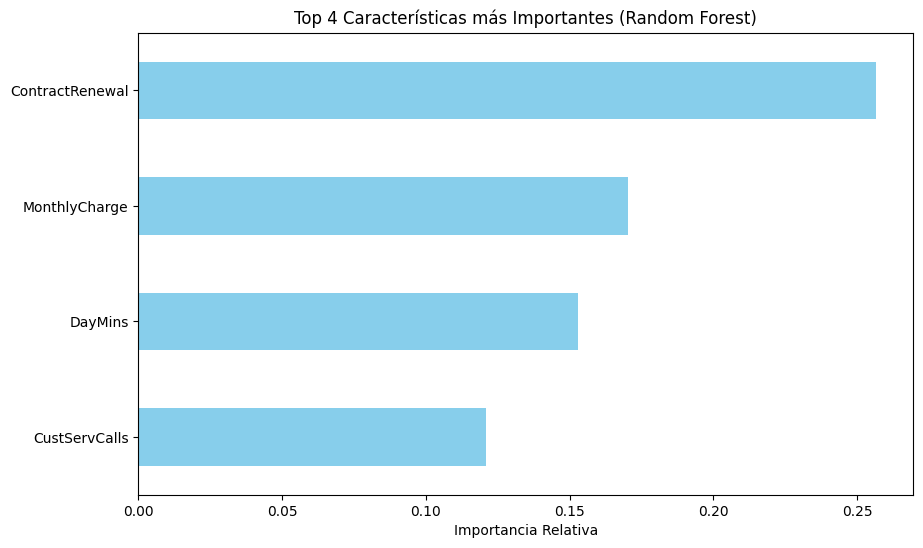

Top 4 Variables:
ContractRenewal    0.256746
MonthlyCharge      0.170475
DayMins            0.152946
CustServCalls      0.120913
dtype: float64


In [52]:
importancias = pd.Series(rf_model.feature_importances_, index=X.columns)
top_4 = importancias.sort_values(ascending=False).head(4)

# Graficar
plt.figure(figsize=(10, 6))
top_4.plot(kind='barh', color='skyblue')
plt.title('Top 4 Características más Importantes (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.gca().invert_yaxis() # Para que la más importante salga arriba
plt.show()

print("Top 4 Variables:")
print(top_4)

### renovacion de contrato es el factor mas determinante de si un cliente se queda o se va.

### el precio es otro factor que determina si el cliente sigue con nosotros o va a explorar otras alternativas

### los minutos diarios, podriamos decir que un cliente se va por que encontró valores mas bajos de minutos en la competencia.

### un cliente que llama demasiado al servicio al cliente es un cliente molesto y que es probable que esté a punto de irse.

6. Realiza una búsqueda de grilla para un modelo Random Forest para los siguientes
rangos de valores para sus hiper parámetros:
* n_estimators: 50- 200 con paso de 10 completando 15 valores
* max_features: [‘sqrt’, ‘log2’, None]

Muestra los mejores hiper parámetros encontrados, la estimación de desempeño en
los datos OOB, y despliega los cuatro atributos más importantes. ¿Tienen sentido
estos? Analiza además las métricas de desempeño, ROC y AUC.

In [53]:
# Definimos los 15 valores para n_estimators (de 50 a 190, o 60 a 200)
n_estimators_range = np.arange(50, 200, 10)

param_grid_rf = {
    'n_estimators': n_estimators_range,
    'max_features': ['sqrt', 'log2', None]
}

In [54]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, max_depth=10, oob_score=True),
    param_grid_rf,
    cv=5,
    scoring='f1', # Optimizamos para F1-Score dado el desbalanceo
    n_jobs=-1
)

In [55]:
rf_grid.fit(x_train_sm, y_train_sm)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=10, oob_score=True,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_features': ['sqrt', 'log2', None],
                         'n_estimators': array([ 50,  60,  70,  80,  90, 100, 110, 120, 130, 140, 150, 160, 170,
       180, 190])},
             scoring='f1')

In [56]:
print(f"Mejor combinación: {rf_grid.best_params_}")
print(f"Mejor F1-Score en validación: {rf_grid.best_score_:.4f}")

Mejor combinación: {'max_features': 'sqrt', 'n_estimators': np.int64(160)}
Mejor F1-Score en validación: 0.9037


### con 160 estimadores tenemos un 0.9 en el f1 por lo que, con aleatoriedad extra, los datos se comportan bien.

In [58]:
# Extraemos el mejor modelo del grid
best_rf = rf_grid.best_estimator_

# Predicciones
y_pred_final = best_rf.predict(x_test)
y_prob_final = best_rf.predict_proba(x_test)[:, 1]

print(f"OOB Score (Estimación de Accuracy interna): {best_rf.oob_score_:.4f}")
print("\n--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_test, y_pred_final))

OOB Score (Estimación de Accuracy interna): 0.9089

--- REPORTE DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       857
           1       0.62      0.81      0.70       143

    accuracy                           0.90      1000
   macro avg       0.79      0.86      0.82      1000
weighted avg       0.92      0.90      0.91      1000



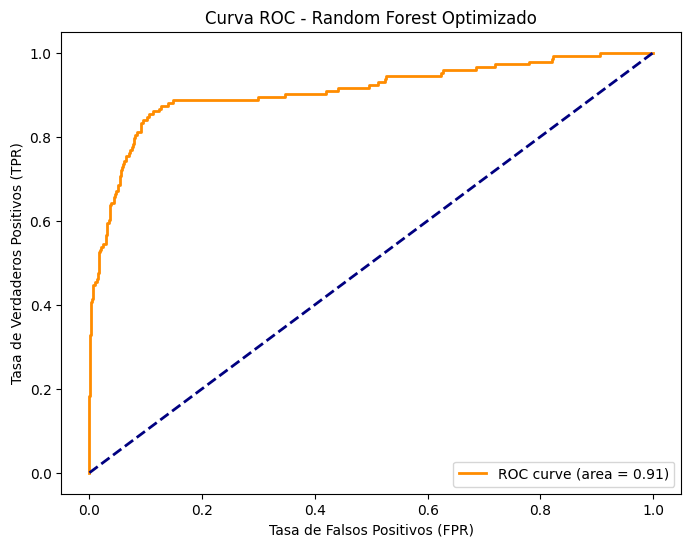

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest Optimizado')
plt.legend(loc="lower right")
plt.show()

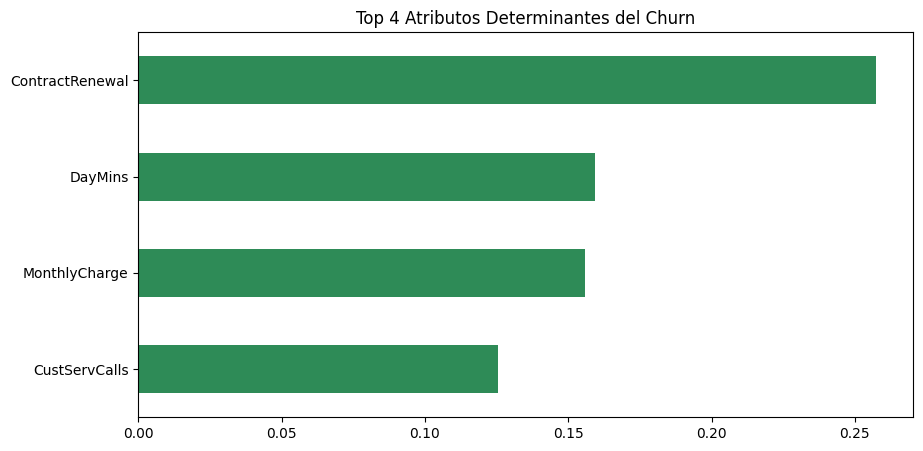

Variables clave para el negocio:
ContractRenewal    0.257544
DayMins            0.159403
MonthlyCharge      0.155894
CustServCalls      0.125355
dtype: float64


In [60]:
importancias = pd.Series(best_rf.feature_importances_, index=X.columns)
top_4_final = importancias.sort_values(ascending=False).head(4)

plt.figure(figsize=(10, 5))
top_4_final.plot(kind='barh', color='seagreen')
plt.title('Top 4 Atributos Determinantes del Churn')
plt.gca().invert_yaxis()
plt.show()

print("Variables clave para el negocio:")
print(top_4_final)

### los modelos casi no cambiaron sus valores. y la curva roc se mantiene en el mismo. quiere decir que el modelo ya no puede entrenarse más

7. Usando el modelo Random Forest con sus hiper parámetros ajustados, muestre los
15 clientes que presentan la mayor propensión a renunciar.

In [61]:
# 1. Obtenemos las probabilidades del set de test
# La columna [:, 1] es la probabilidad de "Hacer Churn"
probabilidades = best_rf.predict_proba(x_test)[:, 1]

# 2. Creamos un DataFrame de resultados
df_resultados = x_test.copy()
df_resultados['Probabilidad_Churn'] = probabilidades
df_resultados['Prediccion'] = y_pred_final

# 3. Ordenamos de mayor a menor probabilidad y tomamos los primeros 15
top_15_riesgo = df_resultados.sort_values(by='Probabilidad_Churn', ascending=False).head(15)

# 4. Mostramos las columnas clave para entender el riesgo
columnas_interes = ['Probabilidad_Churn', 'ContractRenewal', 'MonthlyCharge', 'CustServCalls', 'DayMins']
print("--- TOP 15 CLIENTES CON MAYOR RIESGO DE FUGA ---")
print(top_15_riesgo[columnas_interes])

--- TOP 15 CLIENTES CON MAYOR RIESGO DE FUGA ---
      Probabilidad_Churn  ContractRenewal  MonthlyCharge  CustServCalls  \
605             0.997386                1           76.0              2   
2536            0.997064                1           70.0              0   
3272            0.996878                1           70.0              2   
1078            0.996196                1           74.0              0   
331             0.995824                1           68.0              1   
1878            0.995142                1           70.0              1   
365             0.991227                1           79.0              1   
2924            0.988080                1           69.0              1   
2325            0.987144                1           67.0              2   
1593            0.986816                0           71.0              1   
2155            0.985591                1           68.0              2   
1933            0.982895                1          

### se identificó que la gran mayoria de los clientes que harán churn, renuevan sus contratos. por lo que pueden estár mirando otras opciones mientras pagan sus contratos.

### estos clientes usan una gran cantidad de minutos de llamadas por lo que es muy probable que estén mirando a la comptencia por precios mas bajos en relación a la cantidad de minutos que hablan por telefono.

### finalmente, la gran mayoria solo hace 1 llamada al servicio al cliente por lo que se descarta que sea por problemas tecnicos de la compañía de telefonos como la señal.